# 召回阶段数据分布统计报告


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False


In [5]:
# 加载数据 (修正版：已包含 movieId 列)
DATA_PATH = "../data/ml-32m/ratings.csv"
print("正在加载 32M 评分数据...")
df = pd.read_csv(DATA_PATH, usecols=["userId", "movieId", "rating", "timestamp"], 
                 dtype={"userId": int, "movieId": int, "rating": float, "timestamp": int})


正在加载 32M 评分数据...


## 1. 评分阈值规模统计


In [7]:
total_count = len(df)
ge_30_count = (df["rating"] >= 3.0).sum()
ge_40_count = (df["rating"] >= 4.0).sum()

print(f"总评分记录数: {total_count:,}")
print(f"大于等于 3.0 的记录数: {ge_30_count:,} (占比: {ge_30_count/total_count:.2%})")
print(f"大于等于 4.0 的记录数: {ge_40_count:,} (占比: {ge_40_count/total_count:.2%})")


总评分记录数: 32,000,204
大于等于 3.0 的记录数: 26,283,326 (占比: 82.13%)
大于等于 4.0 的记录数: 15,938,231 (占比: 49.81%)


## 2. 测试集 (最后一个点击) 质量统计


In [8]:
# 严格按时间排序以定位最后一个点击
print("按用户和时间排序中...")
df_sorted = df.sort_values(["userId", "timestamp"], ascending=[True, True])

# 提取每个用户的最后一个点击
last_clicks = df_sorted.groupby("userId").tail(1)
total_users = len(last_clicks)

test_ge_30 = (last_clicks["rating"] >= 3.0).sum()
print(f"总用户数: {total_users:,}")
print(f"最后一个点击评分 >= 3.0 的用户数: {test_ge_30:,} (占比: {test_ge_30/total_users:.2%})")


按用户和时间排序中...
总用户数: 200,948
最后一个点击评分 >= 3.0 的用户数: 174,200 (占比: 86.69%)


## 3. 过滤低分后的序列长度统计


只保留 >= 3.0 样本后的序列长度统计:
count    200892.000000
mean        130.833114
std         213.198287
min           1.000000
25%          32.000000
50%          63.000000
75%         143.000000
max       23557.000000
dtype: float64
序列长度 < 5 的用户数量: 189 (占比: 0.09%)


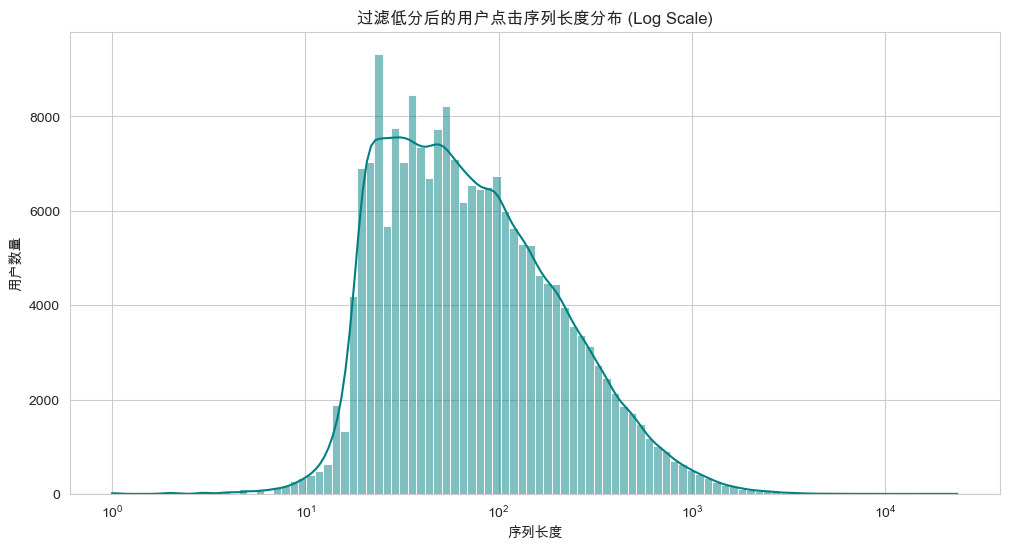

In [9]:
# 只保留评分 >= 3.0 的行为作为正样本序列
pos_df = df[df["rating"] >= 3.0].copy()

# 统计每个用户的有效序列长度
seq_lengths = pos_df.groupby("userId").size()

print("只保留 >= 3.0 样本后的序列长度统计:")
print(seq_lengths.describe())

# 统计序列长度小于5个的用户数量
short_seq_count = (seq_lengths < 5).sum()
print(f"序列长度 < 5 的用户数量: {short_seq_count:,} (占比: {short_seq_count/total_users:.2%})")

# 可视化分布
plt.figure(figsize=(12, 6))
sns.histplot(seq_lengths, bins=100, kde=True, log_scale=True, color="teal")
plt.title("过滤低分后的用户点击序列长度分布 (Log Scale)")
plt.xlabel("序列长度")
plt.ylabel("用户数量")
plt.show()


## 4. 过滤低分后的电影评分统计


只保留 >= 3.0 样本后的电影评分数量统计:
count    73554.000000
mean       357.333741
std       2454.494878
min          1.000000
25%          2.000000
50%          4.000000
75%         24.000000
max      99759.000000
dtype: float64
评分数量 < 5 的电影数量: 37,351 (占比: 50.78%)
评分数量 < 3 的电影数量: 27,619 (占比: 37.55%)
评分数量 <= 1 的电影数量: 18,146 (占比: 24.67%)


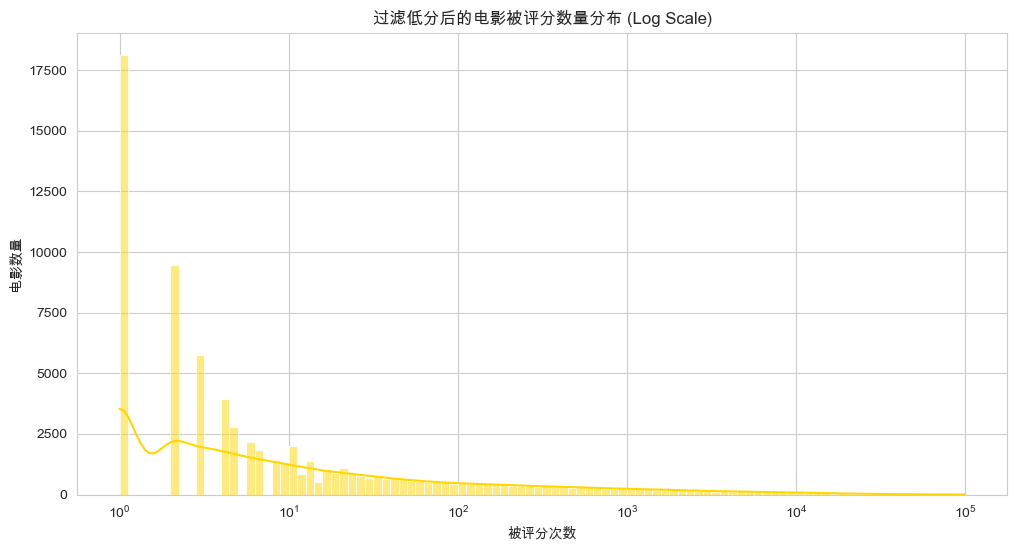

In [11]:
# 统计每部电影的有效评分次数 (针对 >= 3.0 评分)
movie_rating_counts = pos_df.groupby("movieId").size()

print("只保留 >= 3.0 样本后的电影评分数量统计:")
print(movie_rating_counts.describe())

# 统计评分数量小于5个的电影数量
low_count_movies = (movie_rating_counts < 5).sum()
print(f"评分数量 < 5 的电影数量: {low_count_movies:,} (占比: {low_count_movies/len(movie_rating_counts):.2%})")

# 统计评分数量小于3个的电影数量
very_low_count_movies = (movie_rating_counts < 3).sum()
print(f"评分数量 < 3 的电影数量: {very_low_count_movies:,} (占比: {very_low_count_movies/len(movie_rating_counts):.2%})")

# 统计评分数量等于1个的电影数量
one_count_movies = (movie_rating_counts <= 1).sum()
print(f"评分数量 <= 1 的电影数量: {one_count_movies:,} (占比: {one_count_movies/len(movie_rating_counts):.2%})")

# 可视化分布
plt.figure(figsize=(12, 6))
sns.histplot(movie_rating_counts, bins=100, kde=True, log_scale=True, color="gold")
plt.title("过滤低分后的电影被评分数量分布 (Log Scale)")
plt.xlabel("被评分次数")
plt.ylabel("电影数量")
plt.show()


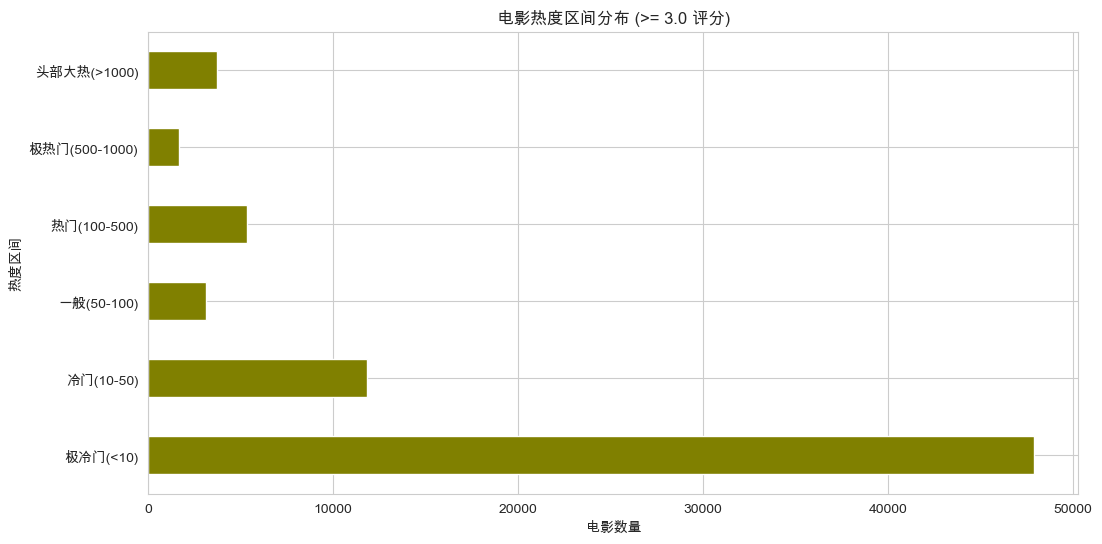

In [7]:
# 统计不同热度区间的电影占比
popularity_bins = [0, 10, 50, 100, 500, 1000, 100000]
popularity_labels = ["极冷门(<10)", "冷门(10-50)", "一般(50-100)", "热门(100-500)", "极热门(500-1000)", "头部大热(>1000)"]
pop_dist = pd.cut(movie_rating_counts, bins=popularity_bins, labels=popularity_labels).value_counts().sort_index()

plt.figure(figsize=(12, 6))
pop_dist.plot(kind="barh", color="olive")
plt.title("电影热度区间分布 (>= 3.0 评分)")
plt.xlabel("电影数量")
plt.ylabel("热度区间")
plt.show()


In [10]:
# 统计高分数据中全部用户点击过的电影总数（去重）
unique_movies = pos_df["movieId"].nunique()
print(f"在评分 >= 3.0 的数据中，用户点击过的独立电影数量: {unique_movies:,}")

在评分 >= 3.0 的数据中，用户点击过的独立电影数量: 73,554
